# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import numpy as np
import pandas as pd

In [33]:
from src.graphics import plot_images, plot_class_distribution, plot_images_by_class, plot_mean_image_by_class
from src.utils import build_class_summary
from src.data_splitting import stratified_train_eval_split

In [10]:
dataset = pd.read_csv("data/fashion_mnist_subset.csv")

## 1. Inspección de los datos

In [11]:
print(dataset.columns)

Index(['pixel_0', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5',
       'pixel_6', 'pixel_7', 'pixel_8', 'pixel_9',
       ...
       'pixel_775', 'pixel_776', 'pixel_777', 'pixel_778', 'pixel_779',
       'pixel_780', 'pixel_781', 'pixel_782', 'pixel_783', 'label'],
      dtype='str', length=785)


In [ ]:
# Separacion entre pixeles y etiquetas
y = dataset["label"]
X = dataset.drop(columns = ["label"])

In [ ]:
print("Shape del dataset completo:", dataset.shape)
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases presentes:", np.unique(y))
print("Rango de pixeles:", X.values.min(), "a", X.values.max())

Shape del dataset completo: (25000, 785)
Shape de X: (25000, 784)
Shape de y: (25000,)
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Rango de pixeles: 0.0 a 1.0


El conjunto de datos utilizado corresponde a un subconjunto de Fashion-MNIST, una base de imágenes de prendas de vestir y accesorios. Cada observación representa una imagen en escala de grises de $28 \times 28$ píxeles, almacenada como un vector de 784 variables, donde cada variable indica la intensidad de un píxel. Los valores de los píxeles se encuentran normalizados en el rango $[0,1]$, donde valores cercanos a 0 representan píxeles oscuros y valores cercanos a 1 representan píxeles claros.

Además, cada imagen cuenta con una etiqueta numérica que indica su clase real: 0 corresponde a remera/top, 1 a pantalón, 2 a pulóver, 3 a vestido, 4 a abrigo, 5 a sandalia, 6 a camisa, 7 a zapatilla, 8 a bolso y 9 a bota. Dado que el objetivo del trabajo es aplicar técnicas de aprendizaje no supervisado, estas etiquetas no se utilizan para entrenar los modelos, sino únicamente como referencia externa para interpretar y evaluar los resultados obtenidos.

### a) Visualización de imágenes

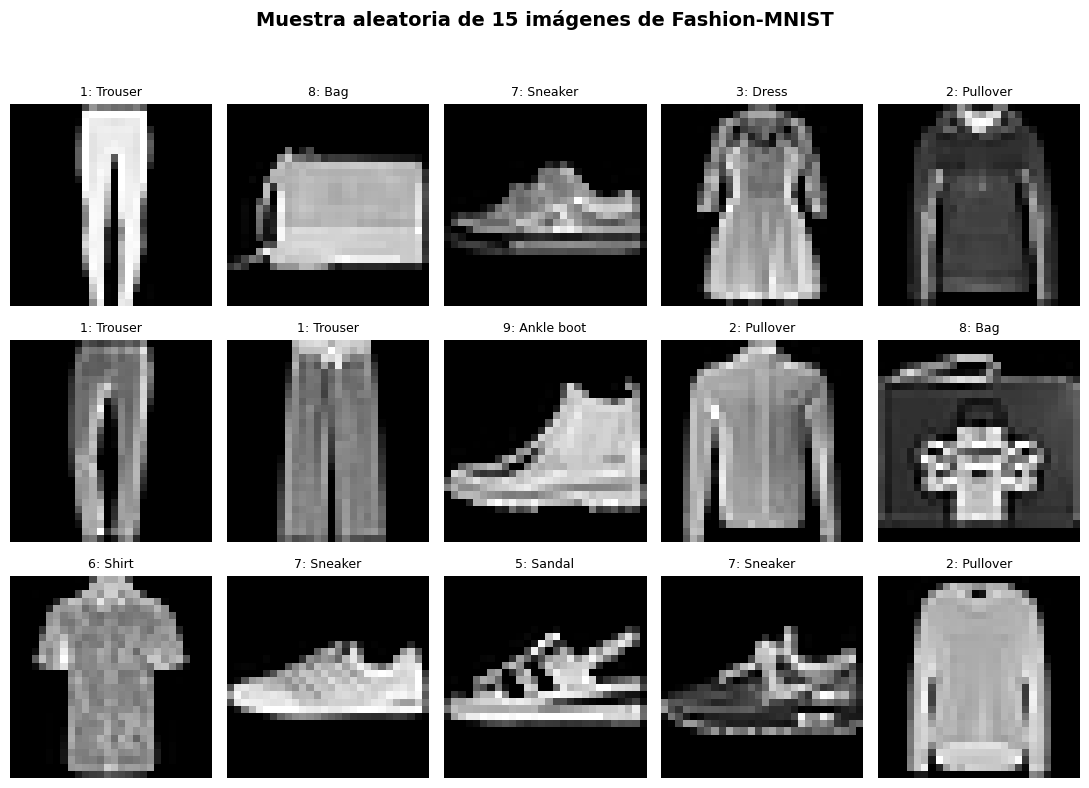

In [14]:
plot_images(X, y, n_images = 15, title = "Muestra aleatoria de 15 imágenes de Fashion-MNIST") 

### b) Análisis Exploratorio de Datos

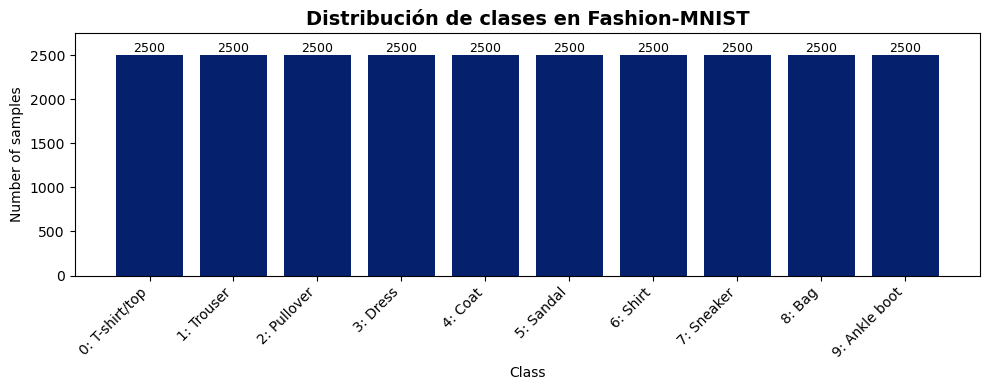

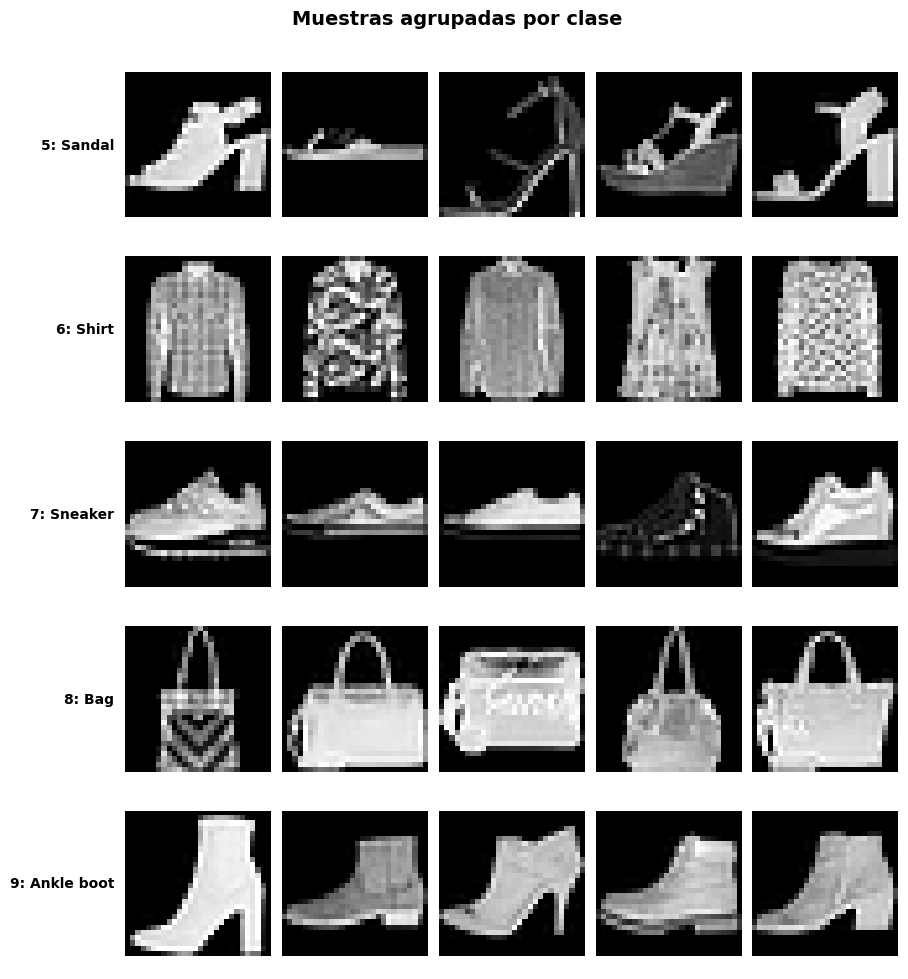

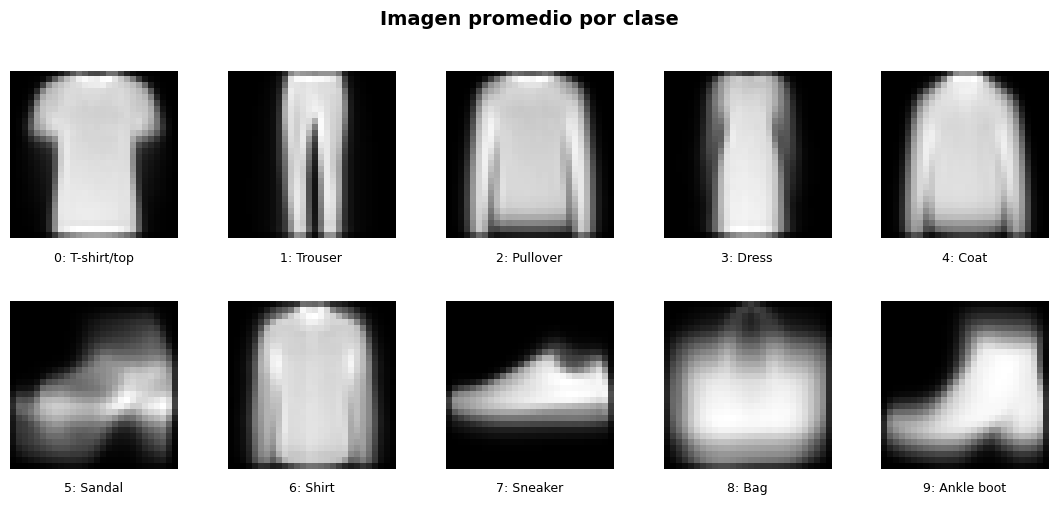

,class_name,count,percentage,mean_intensity,std_intensity,mean_nonzero_pixels
0,T-shirt/top,2500,10.0,0.3284,0.3515,465.99
1,Trouser,2500,10.0,0.2232,0.3437,274.03
2,Pullover,2500,10.0,0.3726,0.3566,507.36
3,Dress,2500,10.0,0.2576,0.3537,335.21
4,Coat,2500,10.0,0.3880,0.3772,472.64
5,Sandal,2500,10.0,0.1378,0.2643,252.65
6,Shirt,2500,10.0,0.3335,0.3409,493.09
7,Sneaker,2500,10.0,0.1684,0.2959,264.23
8,Bag,2500,10.0,0.3557,0.3654,461.16
9,Ankle boot,2500,10.0,0.3008,0.3708,379.03


In [32]:
class_counts = plot_class_distribution(y, title = "Distribución de clases en Fashion-MNIST")
plot_images_by_class(X, y, classes = [5, 6, 7, 8, 9], n_per_class = 5, title = "Muestras agrupadas por clase")
plot_mean_image_by_class(X, y)
build_class_summary(X, y)

In [31]:
print("=== Estadísticas del dataset ===")
print("Cantidad de pixeles por imagen:", X.shape[1])
print("Cantidad de clases:", y.nunique())
print("Diferencia entre clase mayoritaria y minoritaria:", class_counts.max() - class_counts.min())
print("Proporcion minima:", round(class_counts.min() / len(y), 4))
print("Proporcion maxima:", round(class_counts.max() / len(y), 4))
print("Valores faltantes en X:", X.isna().sum().sum())
print("Valores faltantes en y:", y.isna().sum())
print("Promedio global de intensidad:", round(X.to_numpy().mean(), 4))
print("Desvio global de intensidad:", round(X.to_numpy().std(), 4))
print("Porcentaje de pixeles en cero:", round((X.eq(0).sum().sum() / X.size) * 100, 2), "%")

=== Estadísticas del dataset ===
Cantidad de pixeles por imagen: 784
Cantidad de clases: 10
Diferencia entre clase mayoritaria y minoritaria: 0
Proporcion minima: 0.1
Proporcion maxima: 0.1
Valores faltantes en X: 0
Valores faltantes en y: 0
Promedio global de intensidad: 0.2866
Desvio global de intensidad: 0.3533
Porcentaje de pixeles en cero: 50.19 %


A partir de los gráficos y la tabla, se observa que el dataset está perfectamente balanceado: cada una de las 10 clases tiene 2500 imágenes, es decir, representa el 10% del total. Esto es importante porque ninguna clase queda sobrerrepresentada, por lo que los métodos de agrupamiento no deberían verse influenciados por diferencias en la cantidad de ejemplos.

Al mirar las muestras agrupadas por clase, aparece bastante variabilidad dentro de una misma etiqueta. Esto se nota especialmente en sandalias, zapatillas, botas y bolsos, donde cambian las formas, orientaciones y estilos. Por este motivo, no sería raro que algunos métodos no supervisados tengan dificultades para separar las observaciones exactamente según las etiquetas originales.

Las imágenes promedio permiten ver la forma típica de cada categoría. Algunas clases, como pantalón, zapatilla, bolso y bota, tienen siluetas bastante distinguibles. En cambio, prendas como remera/top, pulóver, abrigo y camisa son visualmente más parecidas entre sí, lo que podría hacer más difícil diferenciarlas.

Por último, la tabla muestra que las clases ocupan distintas proporciones de la imagen. Sandalias y zapatillas tienen menos píxeles blancos y una intensidad promedio más baja, mientras que pulóveres, abrigos y camisas ocupan una mayor área visual.

### c) Separando los datos

In [34]:
(xtr, ytr), (xeval, yeval) = stratified_train_eval_split(X, y, eval_size = 0.20)

In [35]:
print("X_train:", xtr.shape)
print("y_train:", ytr.shape)
print("X_eval:", xeval.shape)
print("y_eval:", yeval.shape)

X_train: (20000, 784)
y_train: (20000,)
X_eval: (5000, 784)
y_eval: (5000,)


## 2. Reducción de Dimensionalidad